In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import cv2
from tensorflow.keras.applications.efficientnet import preprocess_input

def preprocess_image(pixels):
    # Convert the string of pixel values into a numpy array
    pixels = np.fromstring(pixels, sep=' ')

    # Check if the number of pixels is correct (should be 2304 for a 48x48 image)
    if pixels.size != 48 * 48:
        print(f"Warning: Expected 2304 pixels, but got {pixels.size}.")
        return None  # Return None or handle the error as you prefer

    # Reshape to 48x48
    pixels = pixels.reshape(48, 48)

    # Ensure the image is in the range [0, 255] and convert to uint8
    pixels = np.uint8(pixels)

    # Convert grayscale (1 channel) image to RGB (3 channels) since EfficientNet expects RGB
    pixels = cv2.cvtColor(pixels, cv2.COLOR_GRAY2RGB)

    # Resize to 48x48 (in case it is not in the required size)
    pixels = cv2.resize(pixels, (48, 48))

    # Expand dimensions to include batch size of 1
    pixels = np.expand_dims(pixels, axis=0)

    # Preprocess for EfficientNet
    return preprocess_input(pixels)

# Example usage with valid pixel string:
pixels = ' '.join(['36', '39', '35', '25', '19', '11', '8', '7', '3', '13', '15', '9', '21', '57', '75', '90', '10', '9', '8', '7', '7', '6', '5', '5', '5', '4', '4', '5', '7', '9', '11', '12', '15', '17', '18', '21', '24', '26', '28', '29', '31', '32', '32', '33', '34', '35', '34', '34', '34', '33', '32', '31', '30', '30', '29', '29', '29', '28'] * 48)  # Ensure 2304 values
processed_image = preprocess_image(pixels)

if processed_image is not None:
    print(processed_image.shape)  # Should print (1, 48, 48, 3)
else:
    print("Image preprocessing failed.")



Image preprocessing failed.


In [ ]:
pip install tensorflow numpy opencv-python scikit-learn matplotlib seaborn


In [ ]:
import numpy as np
import pandas as pd
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load CK+ dataset
data = pd.read_csv('/content/drive/MyDrive/ckextended.csv')
# Assuming 'pixels' column contains space-separated pixel values
data['pixels'] = data['pixels'].apply(lambda x: np.fromstring(x, sep=' ').reshape(48, 48))

# Define ImageDataGenerator with augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    preprocessing_function=preprocess_input
)

# Prepare the data for training and testing
X = np.stack(data['pixels'].values)
X = np.expand_dims(X, axis=-1)
y = data['emotion'].values

# Split into train and test sets (e.g., 80-20 split)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Flow training images in batches of 32 using datagen
train_gen = datagen.flow(X_train, y_train, batch_size=32)
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input).flow(X_test, y_test, batch_size=32)


In [ ]:
# Load the pre-trained model and unfreeze some layers
model = load_model('/content/drive/MyDrive/emotion_recognition_model.h5')

# Unfreeze the last few layers
for layer in model.layers[-20:]:
    layer.trainable = True

# Recompile with a lower learning rate for fine-tuning
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [ ]:
# Define your model architecture with 48x48x1 input shape
model = models.Sequential([
    layers.Input(shape=(48, 48, 1)),  # Updated input shape to match the data
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(8, activation='softmax')  # Adjusted for 8 classes
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=30
)




Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.3985 - loss: 14.8548 - val_accuracy: 0.6413 - val_loss: 1.4087
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.6367 - loss: 1.3560 - val_accuracy: 0.6413 - val_loss: 1.3839
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 141ms/step - accuracy: 0.6272 - loss: 1.3668 - val_accuracy: 0.6413 - val_loss: 1.4261
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - accuracy: 0.6347 - loss: 1.3092 - val_accuracy: 0.6413 - val_loss: 1.3041
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.6561 - loss: 1.2602 - val_accuracy: 0.6630 - val_loss: 1.1795
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.6282 - loss: 1.2919 - val_accuracy: 0.6685 - val_loss: 1.1084
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.6654 - loss: 1.1918 - val_accuracy: 0.6848 - val_loss: 1.1136
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.7064 - loss: 1.0149 - val_accuracy: 0.7391

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Test Accuracy: 85.33%


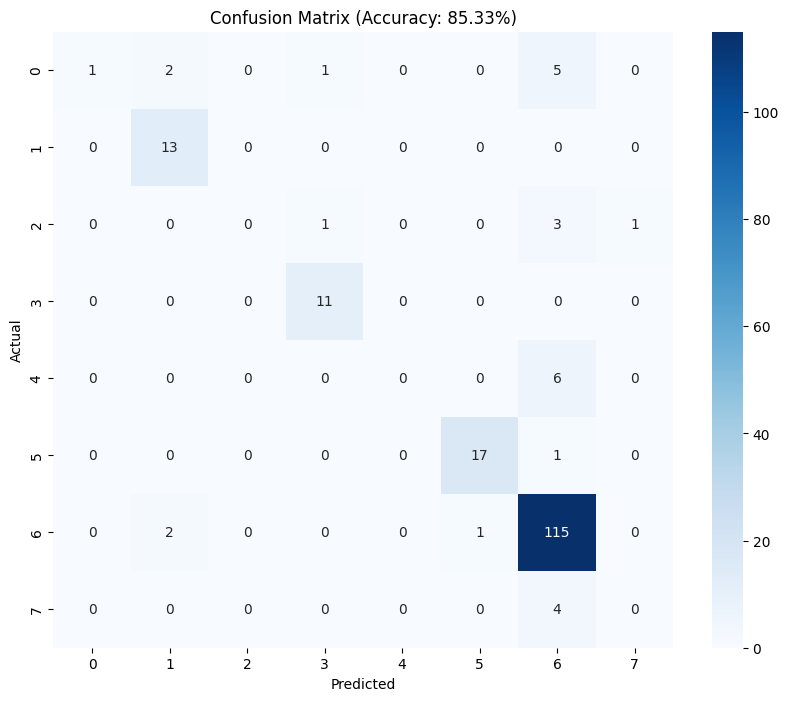

              precision    recall  f1-score   support

           0       1.00      0.11      0.20         9
           1       0.76      1.00      0.87        13
           2       0.00      0.00      0.00         5
           3       0.85      1.00      0.92        11
           4       0.00      0.00      0.00         6
           5       0.94      0.94      0.94        18
           6       0.86      0.97      0.91       118
           7       0.00      0.00      0.00         4

    accuracy                           0.85       184
   macro avg       0.55      0.50      0.48       184
weighted avg       0.80      0.85      0.80       184



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Get predictions on the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Compute accuracy
accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f"Confusion Matrix (Accuracy: {accuracy * 100:.2f}%)")
plt.show()

# Classification report
print(classification_report(y_test, y_pred_classes))


In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.utils import Sequence

class CKPlusDataGenerator(Sequence):
    def __init__(self, csv_path, batch_size=32, img_size=(48, 48), shuffle=True):
        self.data = pd.read_csv(csv_path)
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.data))
        self.on_epoch_end()

    def __len__(self):
        # Number of batches per epoch
        return int(np.floor(len(self.data) / self.batch_size))

    def __getitem__(self, index):
        # Generate indexes for the batch
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_data = self.data.iloc[batch_indexes]

        # Generate data
        X, y = self.__data_generation(batch_data)
        return X, y

    def on_epoch_end(self):
        # Shuffle indexes after each epoch if specified
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __data_generation(self, batch_data):
        # Generates data containing batch_size samples
        X = np.zeros((self.batch_size, *self.img_size, 1), dtype=np.float32)
        y = np.zeros((self.batch_size,), dtype=int)

        for i, (_, row) in enumerate(batch_data.iterrows()):
            # Process pixel values and reshape them to the specified image size
            pixels = np.fromstring(row['pixels'], sep=' ', dtype=np.float32).reshape(self.img_size)
            X[i, :, :, 0] = pixels / 255.0  # Normalize pixel values to [0, 1]
            y[i] = int(row['emotion'])  # Assuming 'emotion' column has integer labels

        return X, y

# Initialize the CK+ data generator
ckplus_csv_path = '/content/drive/MyDrive/ckextended.csv'  # Replace with the actual path
batch_size = 9  # Number of images per batch for visualization
test_gen = CKPlusDataGenerator(csv_path=ckplus_csv_path, batch_size=batch_size)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


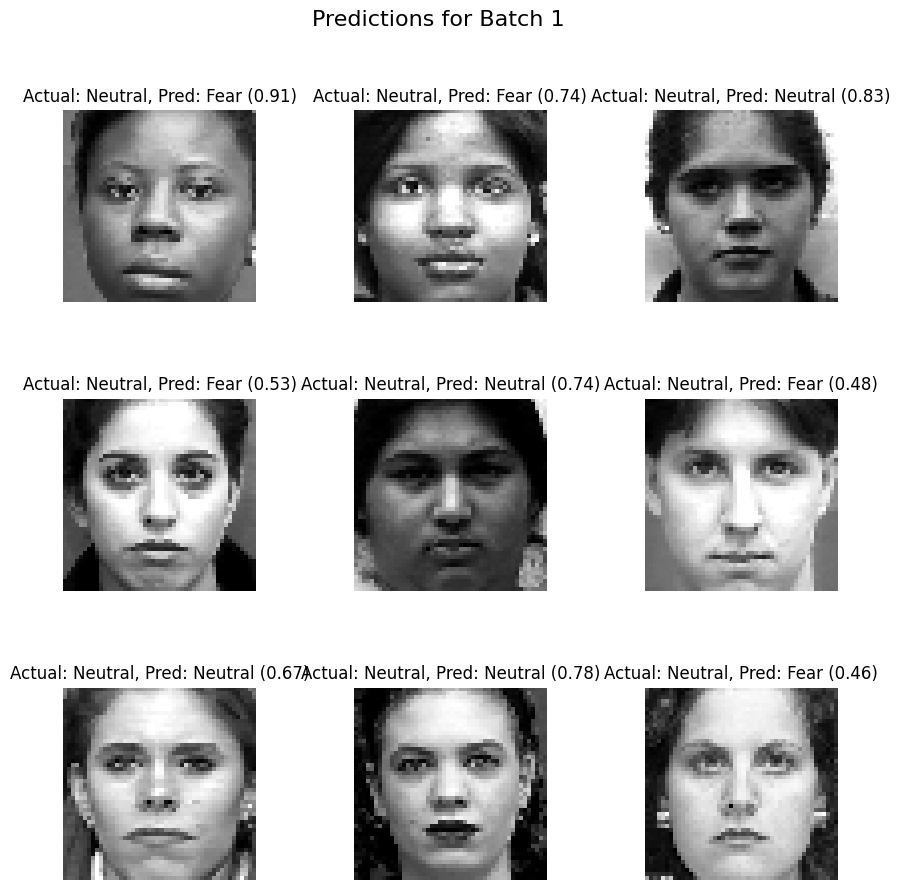

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


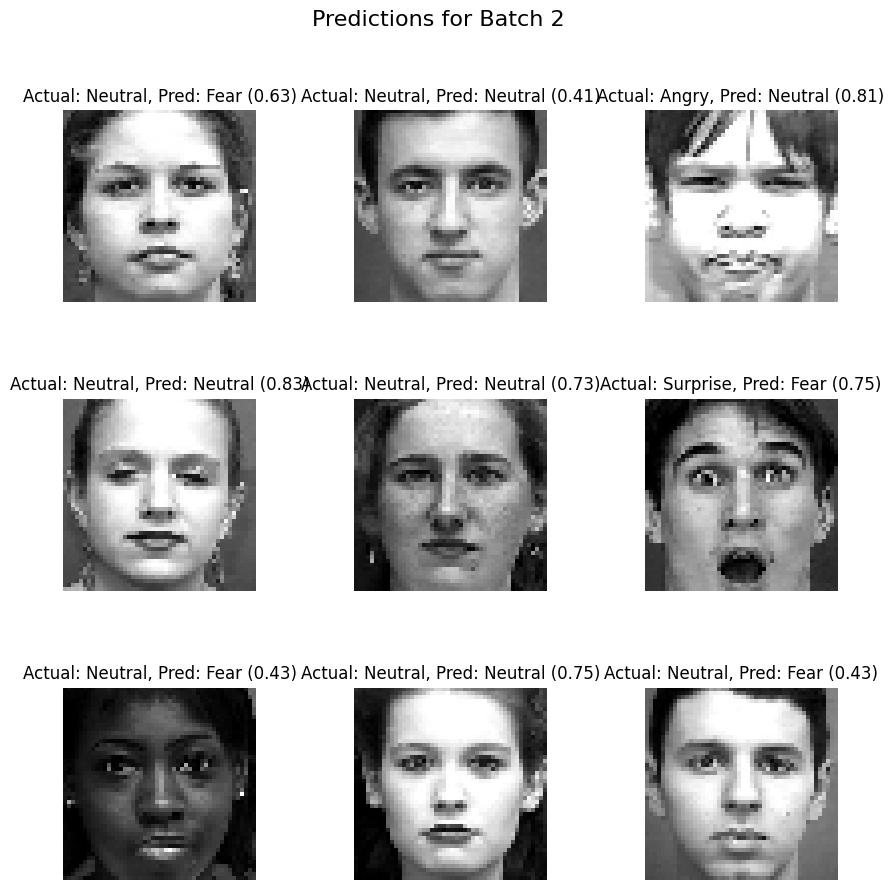

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


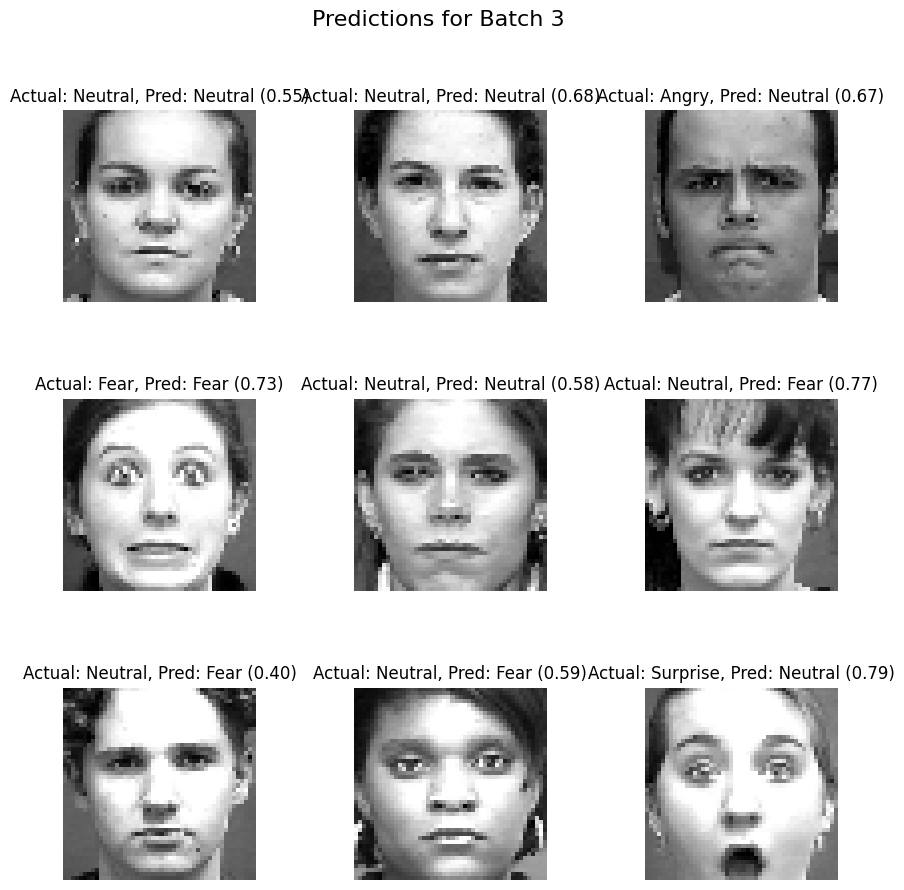

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define the labels for each class
emotion_labels = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

# Define the number of batches you want to display (adjust based on dataset size and batch size)
num_batches_to_display = 3  # Displaying 3 batches as an example
batch_size = test_gen.batch_size  # Using the generator's batch size

for batch_num in range(num_batches_to_display):
    # Get a batch of test images and labels from the CK+ data generator
    test_images, test_labels = test_gen[batch_num]

    # Predict on this batch
    predictions = model.predict(test_images)

    # Convert predictions to class labels
    pred_labels = predictions.argmax(axis=1)

    # Plot the images with actual and predicted labels for the batch
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    fig.subplots_adjust(hspace=0.5, wspace=0.5)
    fig.suptitle(f"Predictions for Batch {batch_num + 1}", fontsize=16)

    for i, ax in enumerate(axes.flat):
        if i >= batch_size:
            break  # Exit if the batch has fewer images than the grid size

        # Extract the image and labels
        image = test_images[i]
        actual_label = test_labels[i]
        pred_label = pred_labels[i]

        # Convert numeric labels to emotion names
        actual_emotion = emotion_labels[actual_label]
        predicted_emotion = emotion_labels[pred_label]

        # Display the image with labels
        ax.imshow(image.squeeze(), cmap="gray")
        pred_confidence = np.max(predictions[i])
        ax.set_title(f"Actual: {actual_emotion}, Pred: {predicted_emotion} ({pred_confidence:.2f})")
        ax.axis("off")

    plt.show()

